In [182]:
from pathlib import Path
import sys

# Allow running the notebook from its folder without installing the package.
repo_root = Path.cwd().resolve()
while repo_root.name != "QuPCA" and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Tomography-based reconstruction experiments for QPCA

This notebook is an exploratory prototype that extends the low-complexity QPCA workflow with an additional tomography step.

The main idea is to start from a small positive semidefinite matrix, encode it into the custom qRAM-style circuit used in the project, run phase estimation, and then test whether the measured amplitudes can be post-processed to recover eigenvalues, signs, and approximate eigenvectors.

Reference paper: *A Low-Complexity Quantum Principal Component Analysis Algorithm*
https://doi.org/10.1109/TQE.2021.3140152

## 1. Prepare a toy matrix and keep track of the reference spectra

These first cells import the project utilities, generate a small positive semidefinite test matrix, and inspect a few closely related variants of it.

The repeated eigendecompositions are not redundant: they are checking how trace normalization and the hand-built reconstruction `BB` change the numerical spectrum before the quantum pipeline starts. The `QPCA().fit(...)` call is used here as a package-level sanity check against the lower-level steps explored later in the notebook.

In [183]:
import itertools
import numpy as np
import pandas as pd
import qiskit.quantum_info as qi
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import PhaseEstimation
from qiskit.circuit.library.data_preparation.state_preparation import StatePreparation
from qiskit.circuit.library.standard_gates import RYGate
from qiskit.visualization import plot_histogram

try:
    from qiskit_aer import Aer
except ImportError:
    from qiskit import Aer

from QPCA import QPCA, generate_matrix
from QPCA.preprocessingUtilities.preprocessing import check_matrix_dimension
from QPCA.quantumUtilities.numpy_matrix import NumPyMatrix

np.random.seed(19)

In [184]:
matrix_dimension = 3
resolution = 8

raw_matrix = generate_matrix(matrix_dimension=matrix_dimension, replicate_paper=False, seed=19)
exact_eigenvalues, exact_eigenvectors = np.linalg.eig(raw_matrix)

normalized_matrix = raw_matrix / np.trace(raw_matrix)
padded_normalized_matrix = check_matrix_dimension(normalized_matrix.copy())

sum_squares = (normalized_matrix ** 2).sum()
input_probabilities = (normalized_matrix ** 2 / sum_squares).flatten()

print(input_probabilities)
print(f"Original shape: {normalized_matrix.shape}, padded shape: {padded_normalized_matrix.shape}")

Matrix:
 [[0.65 0.29 0.92]
 [0.29 0.14 0.44]
 [0.92 0.44 2.07]]

eigenvalue: 0.0070450388722043695 - eigenvector: [ 0.359 -0.933  0.039]
eigenvalue: 0.21492893761037152 - eigenvector: [-0.825 -0.297  0.481]
eigenvalue: 2.6317728594982777 - eigenvector: [-0.437 -0.205 -0.876]
[0.060594   0.01175441 0.12198243 0.01175441 0.00264594 0.02798526
 0.12198243 0.02798526 0.61331586]
Original shape: (3, 3), padded shape: (4, 4)


In [185]:
qpca = QPCA().fit(raw_matrix, resolution=resolution, optimized_qram=False)

qpca.input_matrix.shape, np.linalg.eig(qpca.input_matrix)[1][:matrix_dimension, :matrix_dimension]

((4, 4),
 array([[-0.43714001, -0.82468914,  0.35888219],
        [-0.2051187 , -0.29709624, -0.93255571],
        [-0.87569112,  0.48127086,  0.03928651]]))

In [186]:
eig,e_v=np.linalg.eig(raw_matrix)
#b=np.array([3,1])
#b=np.array([.6,.3,.07,0.03])
b=np.array(exact_eigenvalues) #([9.37,4.42])
#b=np.array([.7,.2,.06,0.04])
BB = e_v@np.diag(b)@e_v.T
BB, np.linalg.eig(BB)
example_matrix2=BB

sum_squares = (example_matrix2**2).sum()
input_probabilities = (example_matrix2**2/sum_squares).flatten()
example_matrix2=example_matrix2/np.trace(example_matrix2)
print(input_probabilities)

[0.060594   0.01175441 0.12198243 0.01175441 0.00264594 0.02798526
 0.12198243 0.02798526 0.61331586]


In [187]:
example_matrix2, np.linalg.eig(example_matrix2)

(array([[0.22776803, 0.10031788, 0.3231667 ],
        [0.10031788, 0.04759571, 0.15478991],
        [0.3231667 , 0.15478991, 0.72463626]]),
 EigResult(eigenvalues=array([0.92221665, 0.07531465, 0.0024687 ]), eigenvectors=array([[-0.43714001, -0.82468914,  0.35888219],
        [-0.2051187 , -0.29709624, -0.93255571],
        [-0.87569112,  0.48127086,  0.03928651]])))

In [188]:
np.trace(raw_matrix)*np.linalg.eig(normalized_matrix)[0]

array([2.63177286, 0.21492894, 0.00704504])

## 2. Recover the qRAM angles and build the custom encoding circuit

The next block reconstructs the binary-tree amplitudes behind the flattened matrix entries and converts them into the list of controlled `RY` rotations used by the old qRAM-style encoder.

This is the last fully custom part of the workflow. The immediate simulator check that follows is there to verify that the handcrafted circuit still prepares the expected amplitude distribution before the notebook moves on to spectral estimation.

In [189]:
def thetas_computation(input_matrix):
    input_matrix = np.asarray(input_matrix, dtype=float)
    flattened_probabilities = (input_matrix ** 2 / (input_matrix ** 2).sum()).flatten()

    combination_levels = []
    max_depth = int(np.ceil(np.log2(input_matrix.size)))
    for depth in range(1, max_depth + 1):
        bitstrings_at_depth = itertools.product([0, 1], repeat=depth)
        combination_levels.append(["".join(map(str, bits)) for bits in bitstrings_at_depth])

    all_combinations = [bitstring for level in combination_levels for bitstring in level]
    leaf_bitstrings = [
        "".join(map(str, bits))
        for bits in itertools.product([0, 1], repeat=max_depth)
    ][: flattened_probabilities.size]

    node_amplitudes = [1.0]
    for bitstring in all_combinations:
        matching_indices = [
            index
            for index, leaf_bitstring in enumerate(leaf_bitstrings)
            if leaf_bitstring.startswith(bitstring)
        ]
        amplitude = np.sqrt(flattened_probabilities[matching_indices].sum())
        print(bitstring, "->", amplitude)
        node_amplitudes.append(amplitude)

    thetas = []
    parent_index = 0
    for right_index in range(1, len(node_amplitudes), 2):
        left_index = right_index + 1
        parent_amplitude = node_amplitudes[parent_index]

        if parent_amplitude != 0:
            thetas.append(2 * np.arccos(node_amplitudes[right_index] / parent_amplitude))
            thetas.append(2 * np.arcsin(node_amplitudes[left_index] / parent_amplitude))
        else:
            thetas.extend([0, 0])

        parent_index += 1

    return thetas, all_combinations

In [190]:
def generate_qram_circuit(input_matrix, thetas, all_combinations):
    right_node_indices = list(range(0, len(thetas), 2))
    right_rotations = list(
        zip(np.array(all_combinations)[right_node_indices], np.array(thetas)[right_node_indices])
    )

    qram_qubit_count = int(np.ceil(np.log2(np.asarray(input_matrix).size)))
    qram_circuit = QuantumCircuit(qram_qubit_count)

    for bitstring, angle in right_rotations:
        target_qubit = len(bitstring) - 1

        if target_qubit == 0:
            qram_circuit.ry(theta=angle, qubit=target_qubit)
            continue

        zero_controls = [qubit for qubit in range(target_qubit) if bitstring[qubit] == "0"]
        controlled_qubits = list(range(len(bitstring)))
        control_count = target_qubit

        if zero_controls:
            qram_circuit.x(zero_controls)

        controlled_ry = RYGate(angle).control(control_count)
        qram_circuit.append(controlled_ry, controlled_qubits)

        if zero_controls:
            qram_circuit.x(zero_controls)

    return qram_circuit

0 -> 0.6218393178827792
1 -> 0.7831448542479735
00 -> 0.4539661264105173
01 -> 0.42496928516864657
10 -> 0.7831448542479735
11 -> 0.0
000 -> 0.2689765907534711
001 -> 0.36570047519084453
010 -> 0.1750177164442658
011 -> 0.38725662327116506
100 -> 0.7831448542479735
101 -> 0.0
110 -> 0.0
111 -> 0.0
0000 -> 0.24615848258712142
0001 -> 0.10841774681188548
0010 -> 0.34925983125896887
0011 -> 0.10841774681188548
0100 -> 0.051438687123834904
0101 -> 0.1672879629152727
0110 -> 0.34925983125896887
0111 -> 0.1672879629152727
1000 -> 0.7831448542479735
1001 -> 0.0
1010 -> 0.0
1011 -> 0.0
1100 -> 0.0
1101 -> 0.0
1110 -> 0.0
1111 -> 0.0


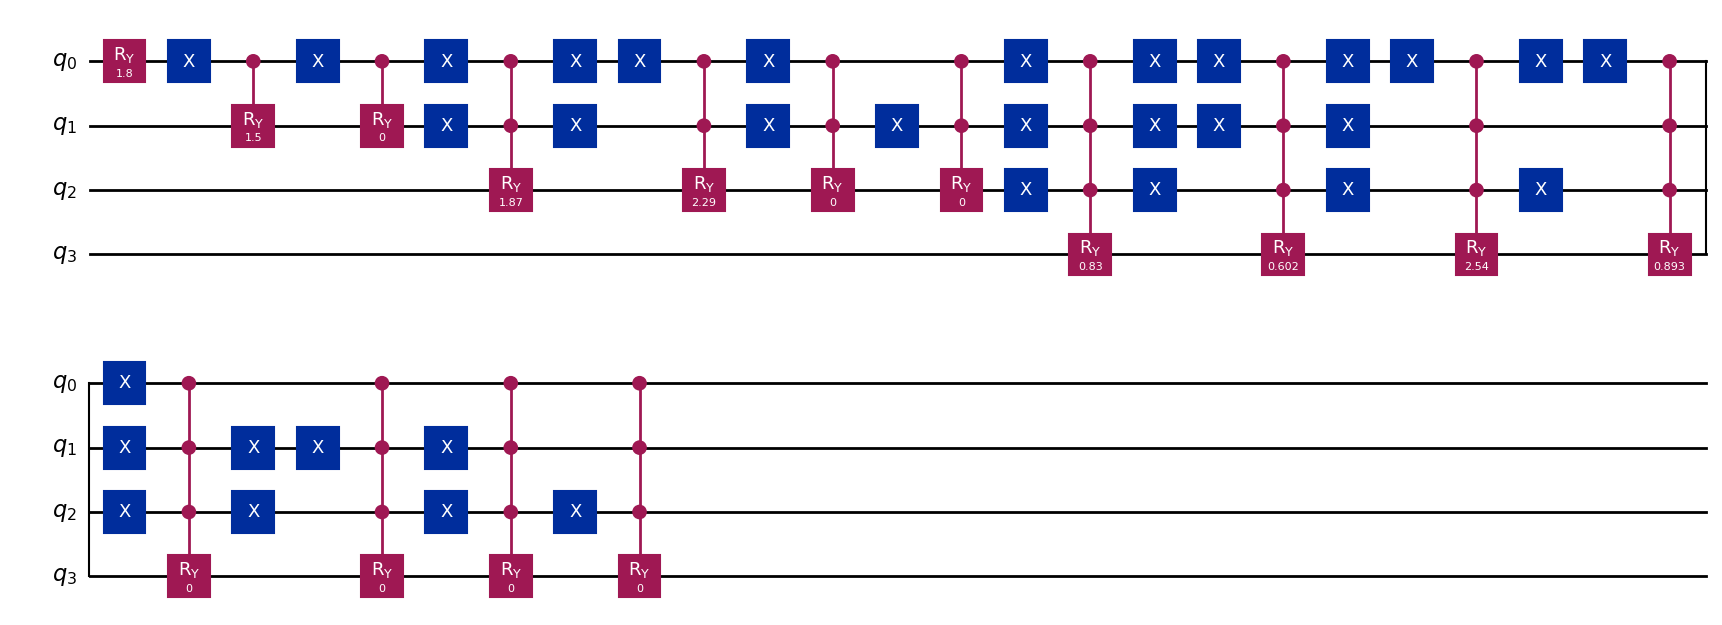

In [191]:
thetas, all_combinations = thetas_computation(normalized_matrix)
matrix_circuit = generate_qram_circuit(normalized_matrix, thetas, all_combinations)
matrix_circuit.draw("mpl")

In [192]:
#Check matrix encoding
backend = Aer.get_backend("statevector_simulator")
job = backend.run(transpile(matrix_circuit, backend=backend))
job.result().get_counts()

{np.str_('0000'): np.float64(0.060593998549594),
 np.str_('0001'): np.float64(0.61331586273508),
 np.str_('0010'): np.float64(0.002645938533024),
 np.str_('0100'): np.float64(0.121982429731044),
 np.str_('0110'): np.float64(0.121982429731043),
 np.str_('1000'): np.float64(0.011754407823766),
 np.str_('1010'): np.float64(0.027985262536342),
 np.str_('1100'): np.float64(0.011754407823766),
 np.str_('1110'): np.float64(0.027985262536342)}

## 3. Promote the normalized matrix to a phase-estimation experiment

Here the notebook wraps the normalized matrix into `NumPyMatrix`, asks Qiskit for the induced unitary, and then builds the `PhaseEstimation` circuit on top of it.

Conceptually this is the bridge from amplitude encoding to spectral encoding: the previous section prepared a state that stores the matrix entries, while this one starts encoding approximate eigenvalues into a dedicated register.

In [193]:
# Unitary used by phase estimation
u_circuit = NumPyMatrix(padded_normalized_matrix, evolution_time=2 * np.pi)
unitary_matrix = qi.Operator(u_circuit).data
unitary_matrix

array([[ 0.90287426+0.22224173j, -0.03738183+0.06437523j,
        -0.00119929-0.36039377j,  0.        +0.j        ],
       [-0.03738183+0.06437523j,  0.98527005+0.03396272j,
        -0.00531069-0.15006559j,  0.        +0.j        ],
       [-0.00119929-0.36039377j, -0.00531069-0.15006559j,
         0.88477381-0.25444512j,  0.        +0.j        ],
       [ 0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  1.        +0.j        ]])

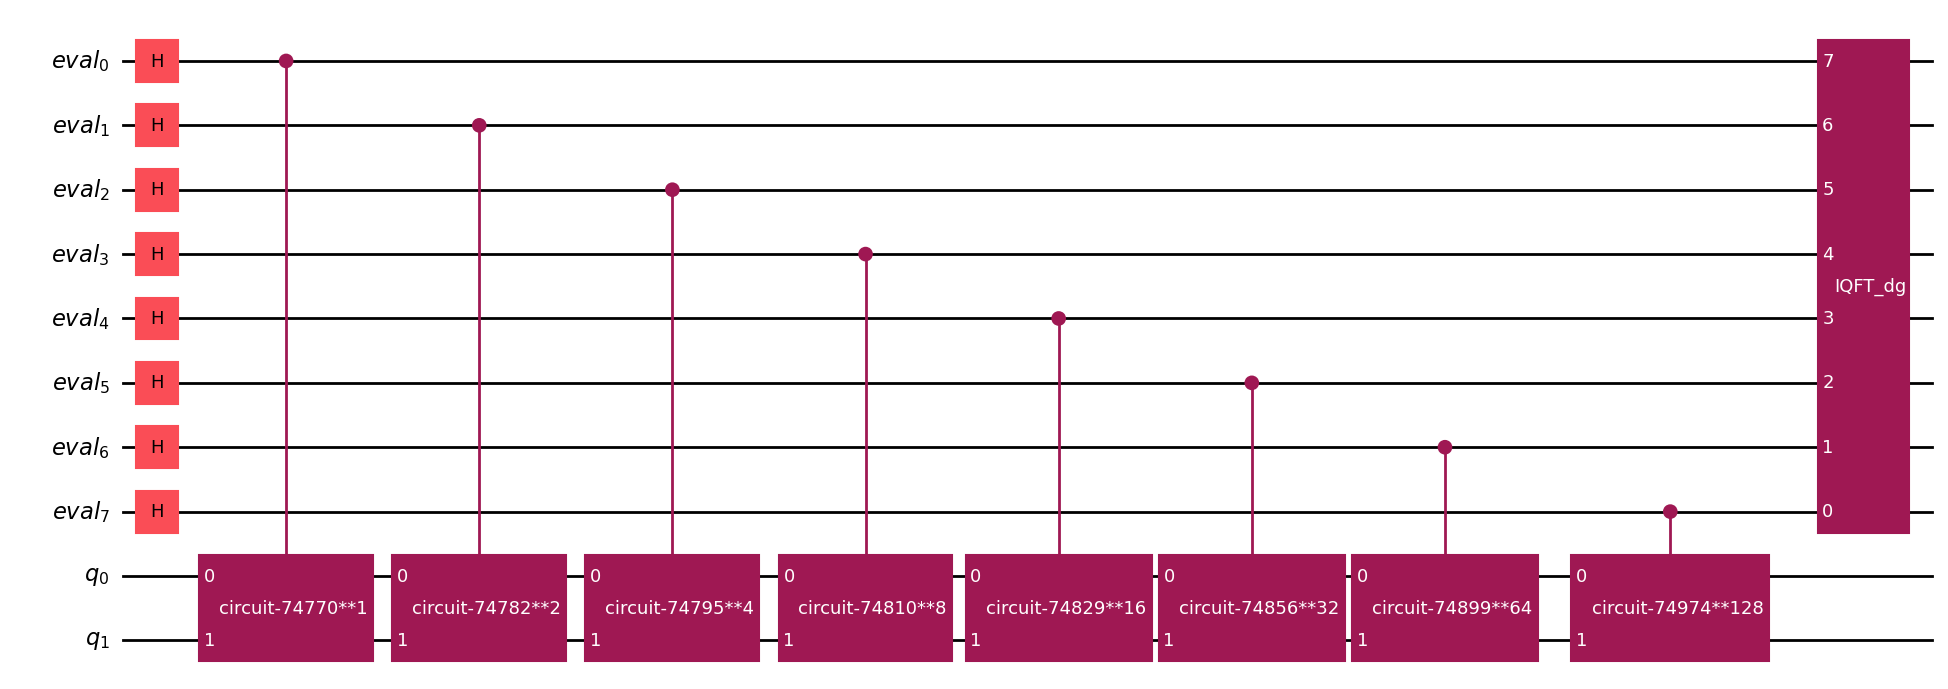

In [194]:
# Phase-estimation circuit
pe = PhaseEstimation(resolution, u_circuit, name="PE")
phase_register_size = pe.qregs[0].size
pe.decompose().draw("mpl", fold=-1)

## 4. Inspect the joint state before measurement

The next cells assemble the full circuit without measurement, simulate its statevector, and create helper objects that will later be reused by the tomography routine.

This is the cleanest checkpoint in the notebook: if the amplitudes already look wrong here, the issue is upstream in the encoding or in phase estimation rather than in the later sign-recovery logic.

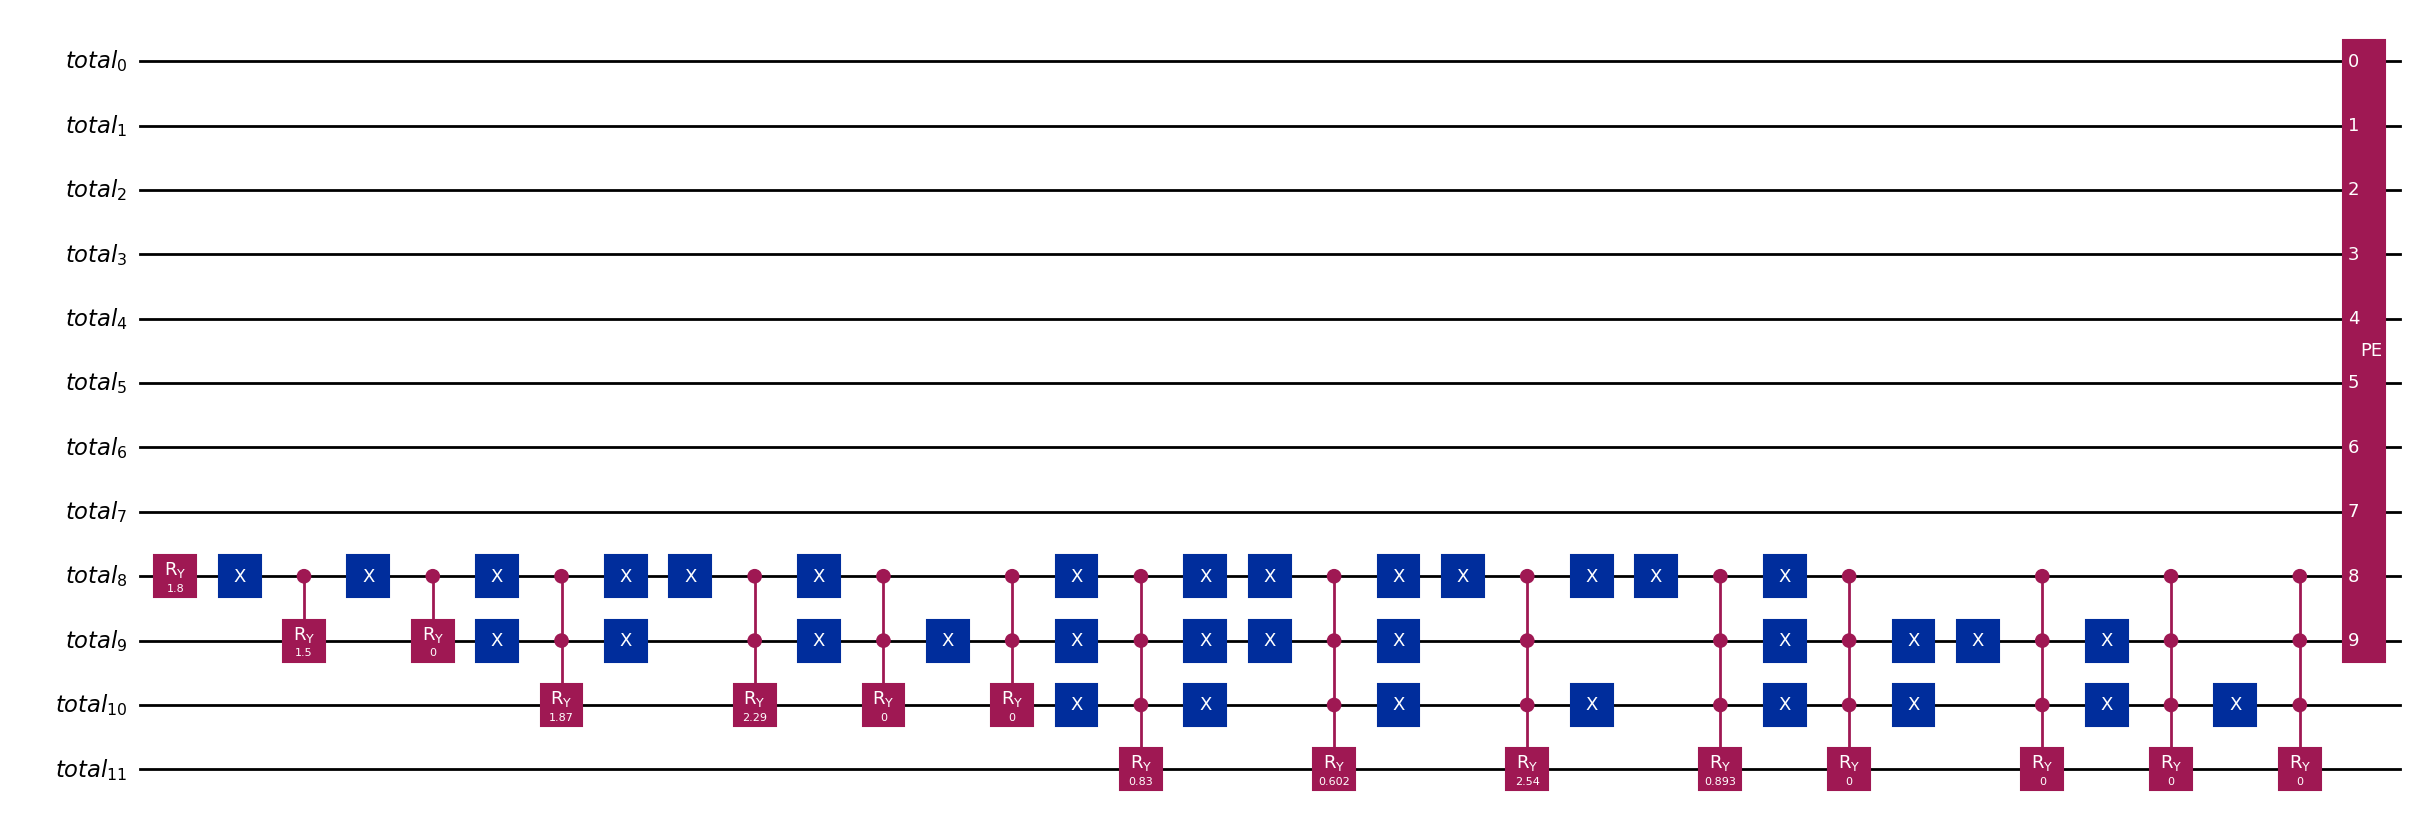

In [195]:
qram_register_size = matrix_circuit.num_qubits
tot_qubit = phase_register_size + qram_register_size

qr_total_sim = QuantumRegister(tot_qubit, "total")
total_circuit_sim = QuantumCircuit(qr_total_sim, name="matrix")

total_circuit_sim.append(matrix_circuit.to_gate(), qr_total_sim[phase_register_size:])
total_circuit_sim.append(pe.to_gate(), qr_total_sim[:pe.num_qubits])

total_circuit_sim.decompose(reps=1).draw("mpl", fold=-1)

In [196]:
# Create the first operator for tomography
op_U=total_circuit_sim.to_gate(label='op_U').control()

In [197]:
backend_total = Aer.get_backend("statevector_simulator")
job = backend_total.run(transpile(total_circuit_sim, backend=backend_total))
statevector = np.asarray(job.result().get_statevector()).round(4)
#plot_histogram(counts)

In [198]:
def attach_bitstrings(vector, bitstrings):
    return list(zip(bitstrings, vector))

In [199]:
bitstrings = [
    "".join(map(str, bits))
    for bits in itertools.product([0, 1], repeat=tot_qubit)
]
sim_statevector = attach_bitstrings(statevector, bitstrings)

In [200]:
phase_register_size, qram_register_size, tot_qubit

(8, 4, 12)

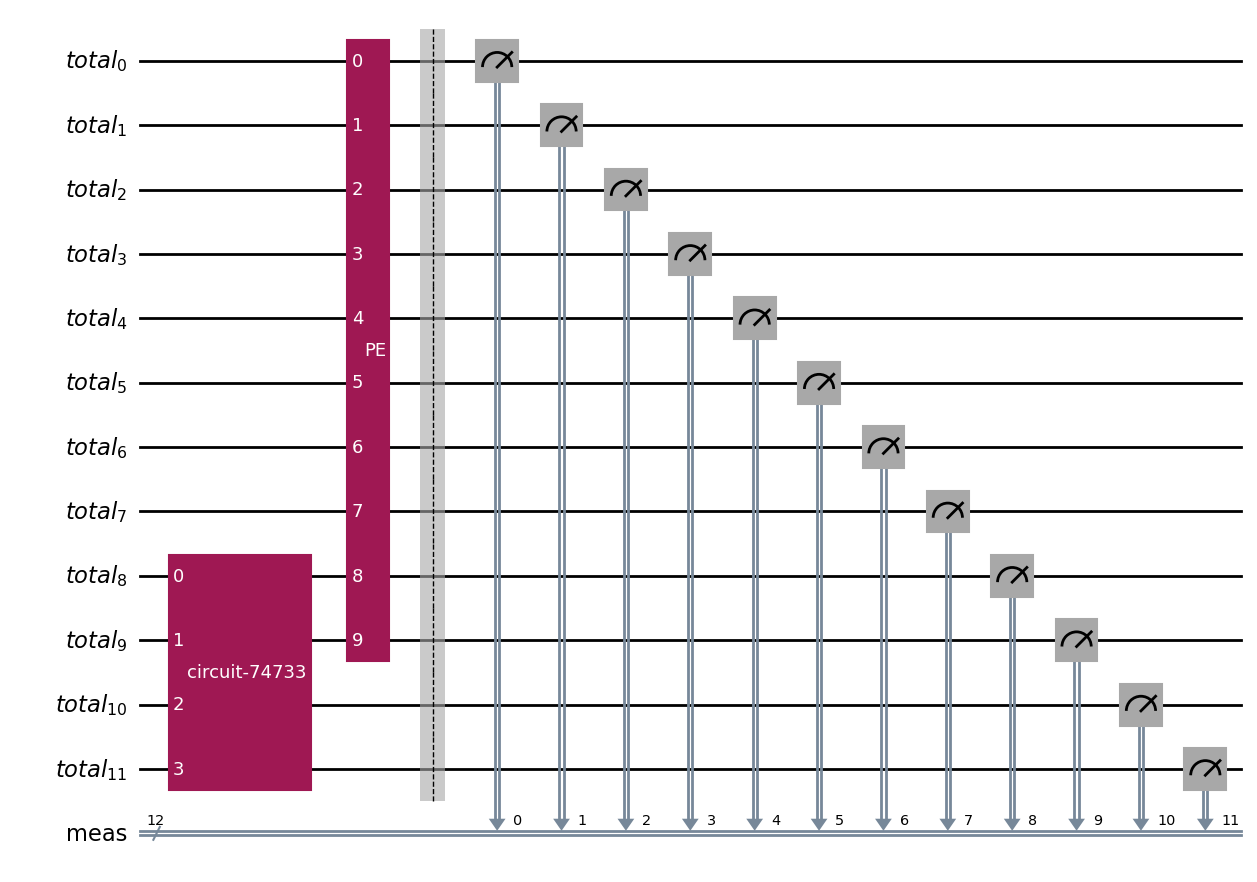

In [201]:
qr_total = QuantumRegister(tot_qubit, "total")

total_circuit = QuantumCircuit(qr_total, name="matrix")

total_circuit.append(matrix_circuit.to_gate(), qr_total[phase_register_size:])
total_circuit.append(pe.to_gate(), qr_total[:pe.num_qubits])
total_circuit.measure_all()
total_circuit.draw("mpl")

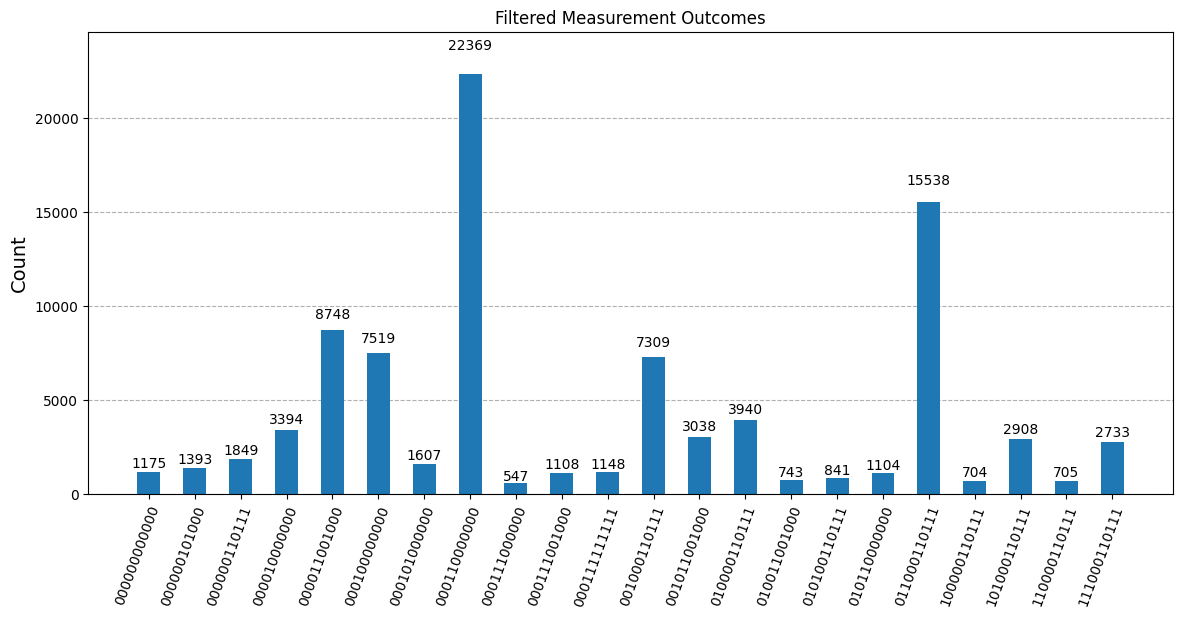

In [202]:
n_shots=100000
backend_total = Aer.get_backend("qasm_simulator")
job = backend_total.run(transpile(total_circuit, backend=backend_total), shots=n_shots)
counts = job.result().get_counts()
# plot_histogram(counts, figsize=(14, 6), title="Measurement Outcomes")
# filter only bitstrings with more than 500 counts
filtered_counts = {k: v for k, v in counts.items() if v > 500}
plot_histogram(filtered_counts, figsize=(14, 6), title="Filtered Measurement Outcomes")

In [203]:
for i in counts:
    counts[i]/=n_shots
#counts

In [204]:
statevector=np.zeros(2**tot_qubit)
for i in counts:
    statevector[int(i,2)]=counts[i]
#statevector

In [205]:
#Create second operator tomography
op_V = StatePreparation(np.sqrt(statevector),label='c_V').control()

## 5. Build the interferometric circuit used for sign recovery

Once the unsigned amplitudes have been extracted from measurement counts, the notebook prepares a second operator and combines it with the first one in a controlled interference circuit.

The purpose of this stage is not to estimate new eigenvalues, but to infer the missing signs of the reconstructed amplitudes so that the final eigenvectors are not limited to absolute values only.

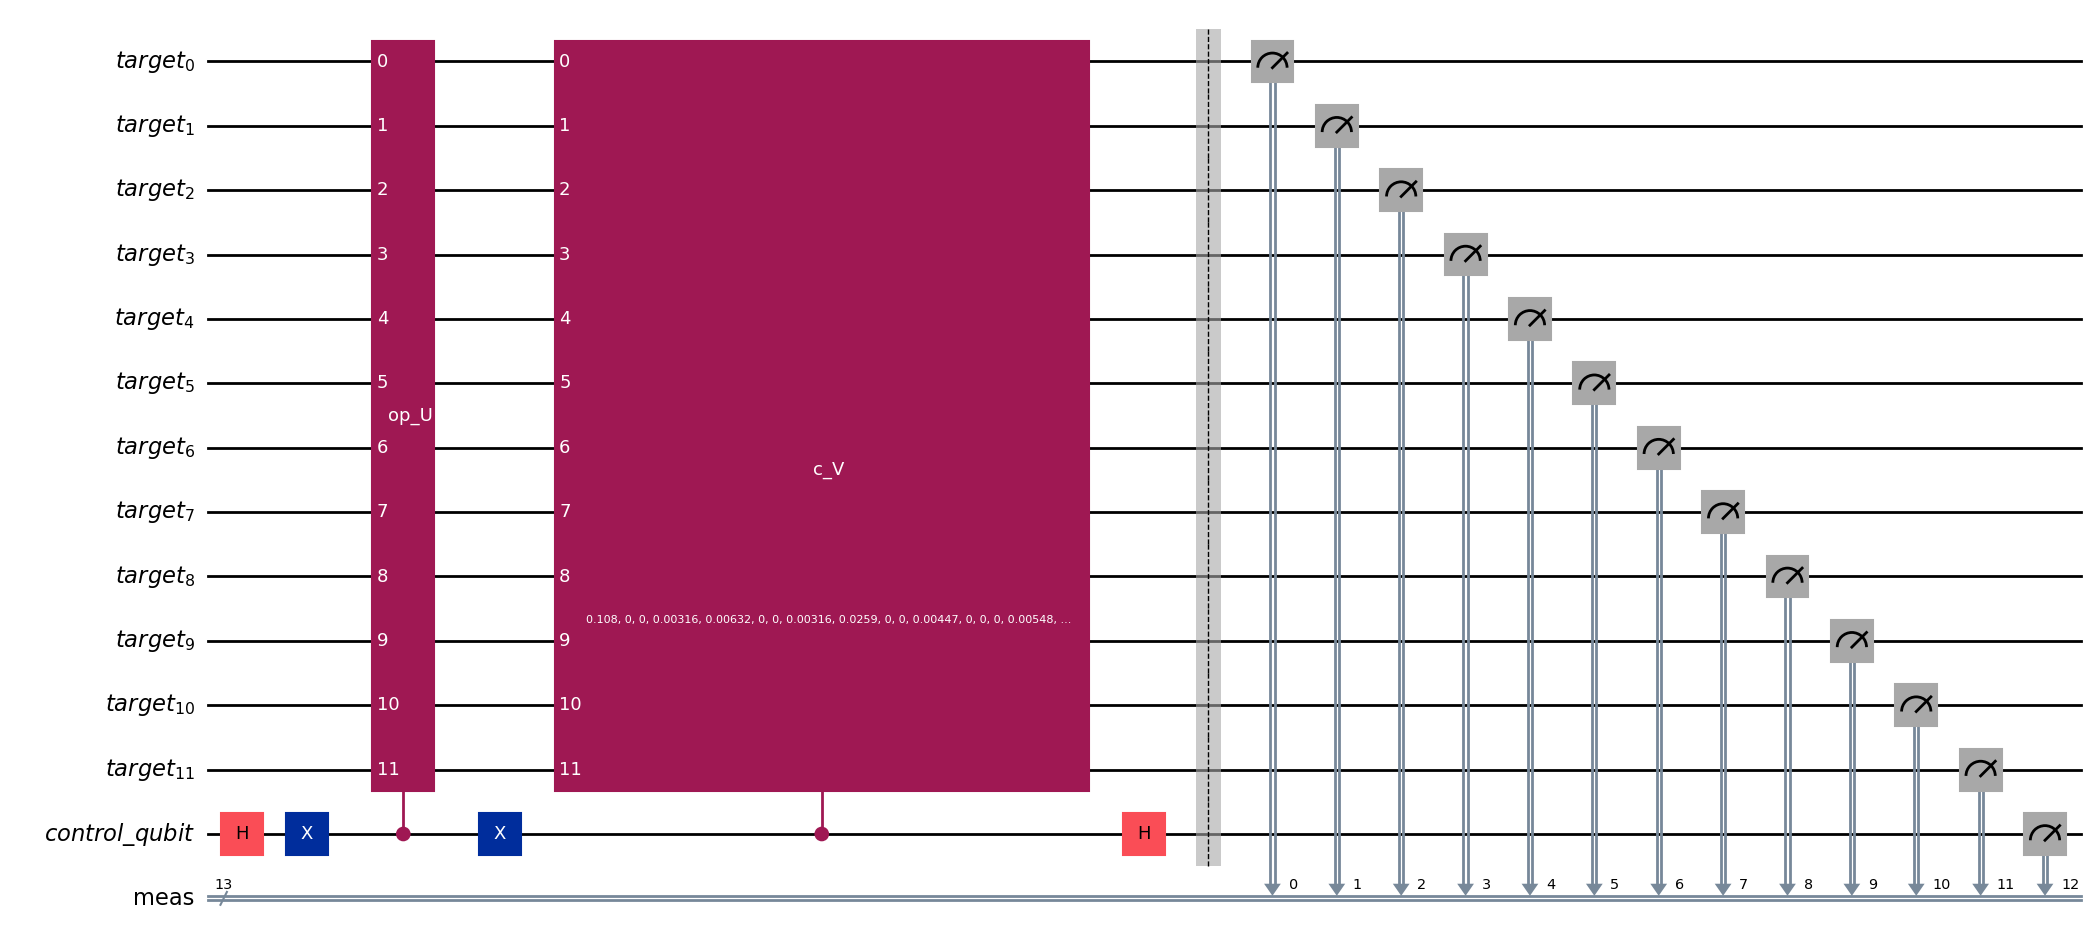

In [206]:
qr_total_xi = QuantumRegister(tot_qubit, 'target')
qr_control = QuantumRegister(1, 'control_qubit')

total_circuit_2 = QuantumCircuit(qr_total_xi, qr_control, name='matrix')
total_circuit_2.h(qr_control)
total_circuit_2.x(qr_control)

total_circuit_2.append(op_U, qr_control[:] + qr_total_xi[:])
total_circuit_2.x(qr_control)
total_circuit_2.append(op_V, qr_control[:] + qr_total_xi[:])
total_circuit_2.h(qr_control)
total_circuit_2.measure_all()
total_circuit_2.draw("mpl", fold=-1)

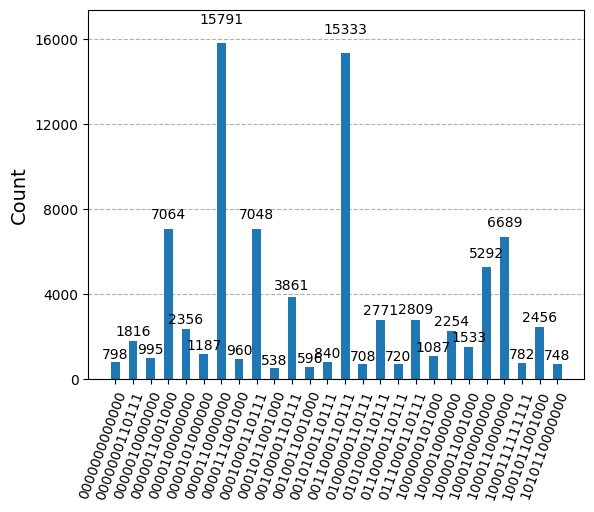

In [207]:
backend_total = Aer.get_backend("qasm_simulator")
job = backend_total.run(transpile(total_circuit_2, backend=backend_total), shots=n_shots)
counts_for_sign = job.result().get_counts()
filtered_counts_for_sign = {k: v for k, v in counts_for_sign.items() if v > 500}
plot_histogram(filtered_counts_for_sign)

In [208]:
#Take only counts with control qubits equal to 0
tmp=np.zeros(2**tot_qubit)
for c in counts_for_sign:
    if c[0]=='0':
        tmp[int(c[1:],2)]=counts_for_sign[c]
#tmp

In [209]:
###Metodo Nannicini

'''tmp_=tmp/(sum(tmp))

sign_diff=[]
sign=[]
x_list=[]
for i in range(len(tmp_)):
    x=(np.sqrt(statevector[i])*0.5)+(((statevector[i])/np.sqrt(statevector[i]))*0.5) - (tmp_[i]/(2*np.sqrt(statevector[i])))
    
    x_list.append(x)
    
    sign_diff.append(np.sign(x)+np.sign((sim_statevector[i][1].real)))
    sign.append(np.sign(x))
    '''

'tmp_=tmp/(sum(tmp))\n\nsign_diff=[]\nsign=[]\nx_list=[]\nfor i in range(len(tmp_)):\n    x=(np.sqrt(statevector[i])*0.5)+(((statevector[i])/np.sqrt(statevector[i]))*0.5) - (tmp_[i]/(2*np.sqrt(statevector[i])))\n\n    x_list.append(x)\n\n    sign_diff.append(np.sign(x)+np.sign((sim_statevector[i][1].real)))\n    sign.append(np.sign(x))\n    '

In [210]:
#Sign estimation
sign_dictionary={}
sign=0
for e, (count, prob) in enumerate(zip(tmp, statevector)):
    if count>0.4*prob*n_shots:
        sign=1
    else:
        sign=-1
    if prob==0:
        sign=1
    sign_dictionary.update({bin(e)[2:].zfill(tot_qubit):sign})

In [211]:
statevector_dictionary={}
for e,key in enumerate(sign_dictionary):
    statevector_dictionary[key]=sign_dictionary[key]*np.sqrt(statevector[e])

#statevector_dictionary

In [212]:
bitstrings = [
    "".join(map(str, bits))
    for bits in itertools.product([0, 1], repeat=tot_qubit)
]
ss = attach_bitstrings(statevector, bitstrings)

## 6. Turn measured amplitudes into a spectrum indexed by binary eigenvalue labels

After sign estimation, the notebook moves from raw arrays to a tabular representation. It associates each amplitude with its computational basis bitstring, extracts the phase-estimation suffix, and aggregates contributions that correspond to the same encoded eigenvalue.

This DataFrame stage is where the notebook stops looking like circuit debugging and starts looking like post-processing: the following cells manipulate a discrete spectrum rather than quantum gates.

In [213]:
df=pd.DataFrame(ss)

df.columns=['state','module']
df

,state,module
0,000000000000,0.01175
1,000000000001,0.00000
2,000000000010,0.00000
3,000000000011,0.00001
4,000000000100,0.00004
...,...,...
4091,111111111011,0.00000
4092,111111111100,0.00000
4093,111111111101,0.00000
4094,111111111110,0.00000


In [214]:
df['lambda']=df['state'].apply(lambda x: x[-resolution:])
df1=df.groupby('lambda').agg({'module':'sum'})
#df1['module_new']=df1['module'].apply(lambda x: np.sqrt(x.real**2 + x.imag**2))
df1=df1.sort_values('module',ascending=False)
df1

,module
lambda,
00110111,0.37267
10000000,0.27289
11001000,0.13994
00000000,0.09207
00101000,0.02184
...,...
00110110,0.00000
10110110,0.00000
01011100,0.00000


In [215]:
tail=df1.reset_index()
tail

,lambda,module
0,00110111,0.37267
1,10000000,0.27289
2,11001000,0.13994
3,00000000,0.09207
4,00101000,0.02184
...,...,...
251,00110110,0.00000
252,10110110,0.00000
253,01011100,0.00000
254,10100011,0.00000


In [216]:
tail['num']=tail['lambda'].apply(lambda x :int(x[::-1],base=2)/(2**resolution))

In [217]:
tail.head(10)

,lambda,module,num
0,00110111,0.37267,0.921875
1,10000000,0.27289,0.003906
2,11001000,0.13994,0.074219
3,00000000,0.09207,0.000000
4,00101000,0.02184,0.078125
5,01000000,0.01978,0.007812
6,11111111,0.01407,0.996094
7,01001000,0.00691,0.070312
8,11000000,0.00670,0.011719
9,01111111,0.00556,0.992188


In [218]:
np.linalg.eig(normalized_matrix)

EigResult(eigenvalues=array([0.92221665, 0.07531465, 0.0024687 ]), eigenvectors=array([[-0.43714001, -0.82468914,  0.35888219],
       [-0.2051187 , -0.29709624, -0.93255571],
       [-0.87569112,  0.48127086,  0.03928651]]))

## 7. Isolate the meaningful peaks of the estimated spectrum

This block applies two pragmatic heuristics to the aggregated spectrum: an adaptive `find_peaks` threshold and a simpler spacing rule that keeps only sufficiently separated candidates.

The goal is to reduce duplicated bins and map the dominant binary strings back to the closest classical eigenvalues of the normalized matrix. In other words, this is the notebook's hand-built peak-selection layer.

In [219]:
from scipy.signal import find_peaks

peaks=[]
nums_peaks=[]
offset=1/n_shots
stop=False
while stop==False:
    right_thresholds=find_peaks(tail.sort_values(['num'])['module'],threshold=offset)[1]['right_thresholds']
    left_thresholds=find_peaks(tail.sort_values(['num'])['module'],threshold=offset)[1]['left_thresholds']
    mean=(right_thresholds+left_thresholds)/2
    p=find_peaks(tail.sort_values(['num'])['module'],threshold=offset)[0]
    if len(p)>len(normalized_matrix):
        offset+=1/n_shots
    else:
        stop=True
        for i in p:
            el = tail.sort_values(['num']).iloc[i]
            nums_peaks.append(el['num'])
            peaks.append(el['lambda'])

sorted_peaks=np.array(peaks)[mean.argsort()[::-1]]
sorted_num_peaks=np.array(nums_peaks)[mean.argsort()[::-1]]
peaks,np.array(nums_peaks)

(['10000000', '11001000', '00110111'],
 array([0.00390625, 0.07421875, 0.921875  ]))

In [220]:
peak_candidates = sorted_num_peaks
peak_candidates

array([0.921875  , 0.00390625, 0.07421875])

In [221]:
weak_peak_values = np.array(nums_peaks)[mean == np.amin(mean)]
non_weak_peak_values = np.array(nums_peaks)[mean != np.amin(mean)]

{
    "weak_peak_values": weak_peak_values,
    "non_weak_peak_values": non_weak_peak_values,
}

{'weak_peak_values': array([0.07421875]),
 'non_weak_peak_values': array([0.00390625, 0.921875  ])}

In [222]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

In [223]:
closest_candidate_distance = np.inf
value_to_keep = None

for candidate_peak in weak_peak_values:
    nearest_classical_eigenvalue = find_nearest(
        np.linalg.eig(normalized_matrix)[0], candidate_peak
    )
    distance_to_classical = abs(nearest_classical_eigenvalue - candidate_peak)
    if distance_to_classical < closest_candidate_distance:
        closest_candidate_distance = distance_to_classical
        value_to_keep = candidate_peak

values_not_to_keep = [peak for peak in weak_peak_values if peak != value_to_keep]

{
    "kept_weak_peak": value_to_keep,
    "discarded_weak_peaks": values_not_to_keep,
    "distance_to_nearest_classical_eigenvalue": closest_candidate_distance,
}

{'kept_weak_peak': np.float64(0.07421875),
 'discarded_weak_peaks': [],
 'distance_to_nearest_classical_eigenvalue': np.float64(0.001095897711733268)}

In [224]:
discarded_peak_indices = [
    index for index, peak in enumerate(sorted_num_peaks) if peak in values_not_to_keep
]
discarded_peak_indices

[]

In [225]:
values_not_to_keep

[]

In [226]:
new_peaks=[v for v in sorted_num_peaks if v not in values_not_to_keep]
new_peaks

[np.float64(0.921875), np.float64(0.00390625), np.float64(0.07421875)]

In [227]:
right_thresholds,left_thresholds

(array([0.25311, 0.1181 , 0.36929]), array([0.18082, 0.13303, 0.37015]))

In [228]:
(right_thresholds+left_thresholds)/2

array([0.216965, 0.125565, 0.36972 ])

In [229]:
sorted_peaks,sorted_num_peaks,right_thresholds

(array(['00110111', '10000000', '11001000'], dtype='<U8'),
 array([0.921875  , 0.00390625, 0.07421875]),
 array([0.25311, 0.1181 , 0.36929]))

### Match each estimated peak to the closest classical eigenvalue

The next cells reconcile the peak positions found from tomography with the classical eigendecomposition of the normalized matrix.

The intent is to build a stable ordering: each relevant peak is mapped to the closest classical eigenvalue, duplicates are suppressed, and the resulting list is later used to reorder the classical reference eigenvectors.

In [230]:
classical_eigenvalue_usage = {
    eigenvalue: False for eigenvalue in np.linalg.eig(normalized_matrix)[0]
}
classical_eigenvalue_usage

{np.float64(0.9222166543703645): False,
 np.float64(0.07531464771173327): False,
 np.float64(0.0024686979179016242): False}

In [252]:
for estimated_peak_value in sorted_num_peaks:
    nearest_classical_eigenvalue = find_nearest(
        np.linalg.eig(normalized_matrix)[0], estimated_peak_value
    )
    print(nearest_classical_eigenvalue)
    if not classical_eigenvalue_usage[nearest_classical_eigenvalue]:
        classical_eigenvalue_usage[nearest_classical_eigenvalue] = True

print(classical_eigenvalue_usage)

0.9222166543703645
0.0024686979179016242
0.07531464771173327
{np.float64(0.9222166543703645): True, np.float64(0.07531464771173327): True, np.float64(0.0024686979179016242): True}


In [253]:
matched_classical_eigenvalues = [
    eigenvalue
    for eigenvalue, was_matched in classical_eigenvalue_usage.items()
    if was_matched
]
unmatched_classical_eigenvalues = [
    eigenvalue
    for eigenvalue, was_matched in classical_eigenvalue_usage.items()
    if not was_matched
]

{
    "matched_classical_eigenvalues": matched_classical_eigenvalues,
    "unmatched_classical_eigenvalues": unmatched_classical_eigenvalues,
}

{'matched_classical_eigenvalues': [np.float64(0.9222166543703645),
  np.float64(0.07531464771173327),
  np.float64(0.0024686979179016242)],
 'unmatched_classical_eigenvalues': []}

In [255]:
if unmatched_classical_eigenvalues:
    matched_classical_eigenvalues.extend(unmatched_classical_eigenvalues[:1])
else:
    matched_classical_eigenvalues = sorted(
        matched_classical_eigenvalues, reverse=True
    )

new_original_eigenvalues = matched_classical_eigenvalues
new_original_eigenvalues

[np.float64(0.9222166543703645),
 np.float64(0.07531464771173327),
 np.float64(0.0024686979179016242)]

In [256]:
np.linalg.eig(normalized_matrix),np.linalg.eig(normalized_matrix)[1][:,1]

(EigResult(eigenvalues=array([0.92221665, 0.07531465, 0.0024687 ]), eigenvectors=array([[-0.43714001, -0.82468914,  0.35888219],
        [-0.2051187 , -0.29709624, -0.93255571],
        [-0.87569112,  0.48127086,  0.03928651]])),
 array([-0.82468914, -0.29709624,  0.48127086]))

In [257]:
new_idx=[]
for i in new_original_eigenvalues:
    for j in range(len(np.linalg.eig(normalized_matrix)[0])):
        if i==np.linalg.eig(normalized_matrix)[0][j]:
            new_idx.append(np.linalg.eig(normalized_matrix)[1][:,j])
            
new_idx=np.array(new_idx)

In [258]:
new_idx.reshape(matrix_dimension, matrix_dimension).T

array([[-0.43714001, -0.82468914,  0.35888219],
       [-0.2051187 , -0.29709624, -0.93255571],
       [-0.87569112,  0.48127086,  0.03928651]])

In [259]:
peaks=[]
nums_peaks=[]
peaks.append(tail.iloc[0]['lambda'])
nums_peaks.append(tail.iloc[0]['num'])
for i in range(1,len(tail)):
    
    #for n_ in nums_peaks:
        
    if any(abs(tail.iloc[i]['num']-n_)<= 4/(2**resolution) for n_ in nums_peaks):
        #if any(abs(tail1.iloc[i]['num']-n_)/n_<= 0.2 for n_ in nums_peaks):
        pass
    else:
           
        nums_peaks.append(tail.iloc[i]['num'])
        peaks.append(tail.iloc[i]['lambda'])
        pass
    if len(peaks)==len(normalized_matrix):
        break
    #print(tail.iloc[i])

In [260]:
peaks,np.array(nums_peaks)

(['00110111', '10000000', '11001000'],
 array([0.921875  , 0.00390625, 0.07421875]))

In [261]:
np.linalg.eig(normalized_matrix)

EigResult(eigenvalues=array([0.92221665, 0.07531465, 0.0024687 ]), eigenvectors=array([[-0.43714001, -0.82468914,  0.35888219],
       [-0.2051187 , -0.29709624, -0.93255571],
       [-0.87569112,  0.48127086,  0.03928651]]))

<Axes: xlabel='num'>

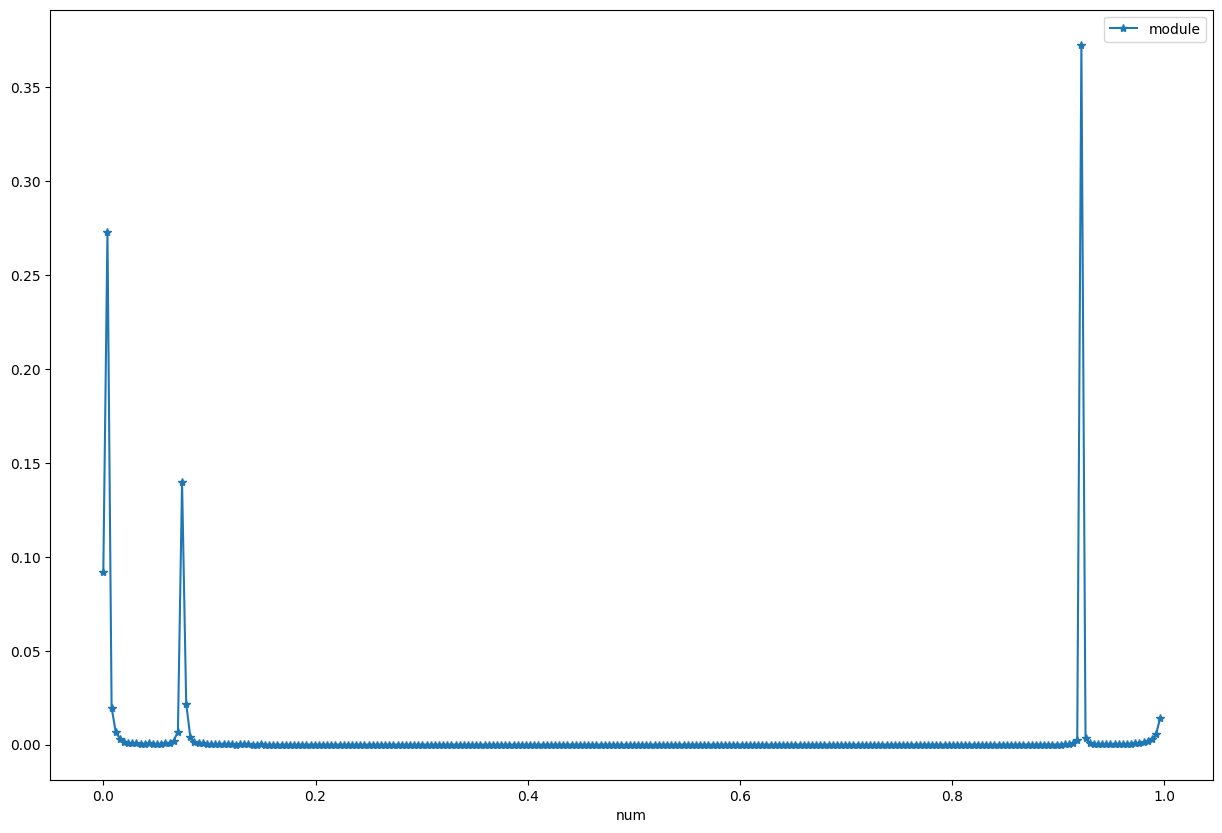

In [262]:
tail[['num','module']].sort_values('num').set_index('num').plot(style='-*',figsize=(15,10))

In [263]:
'''lambdas=df1.tail(len(normalized_matrix)).index.values
lambdas'''

'lambdas=df1.tail(len(normalized_matrix)).index.values\nlambdas'

In [264]:
lambdas=peaks
lambdas

['00110111', '10000000', '11001000']

### Build a signed amplitude table before reconstructing eigenvectors

From this point on, the notebook treats the recovered state as tabular data rather than as a circuit output.

The next cells attach the sign estimates to each amplitude, keep the eigenvalue register bits alongside each state label, and prepare the slices that will later be turned into approximate eigenvectors.

In [278]:
df = pd.DataFrame(ss, columns=["state", "module"])
df["lambda"] = df["state"].apply(lambda bitstring: bitstring[-resolution:])
df["sign"] = np.array(list(sign_dictionary.values()))
df

,state,module,lambda,sign
0,000000000000,0.01175,00000000,1
1,000000000001,0.00000,00000001,1
2,000000000010,0.00000,00000010,1
3,000000000011,0.00001,00000011,1
4,000000000100,0.00004,00000100,-1
...,...,...,...,...
4091,111111111011,0.00000,11111011,1
4092,111111111100,0.00000,11111100,1
4093,111111111101,0.00000,11111101,1
4094,111111111110,0.00000,11111110,1


,state,module,lambda,sign
0,000000000000,0.01175,00000000,1
1,000000000001,0.00000,00000001,1
2,000000000010,0.00000,00000010,1
3,000000000011,0.00001,00000011,1
4,000000000100,0.00004,00000100,-1
...,...,...,...,...
4091,111111111011,0.00000,11111011,1
4092,111111111100,0.00000,11111100,1
4093,111111111101,0.00000,11111101,1
4094,111111111110,0.00000,11111110,1


In [277]:
df["signed_module"] = df["module"] * df["sign"]
df["module"] = df["signed_module"]
df = df.fillna(0)
df

,state,module,lambda,sign,signed_module
0,000000000000,0.01175,00000000,1,0.01175
1,000000000001,0.00000,00000001,1,0.00000
2,000000000010,0.00000,00000010,1,0.00000
3,000000000011,0.00001,00000011,1,0.00001
4,000000000100,-0.00004,00000100,-1,-0.00004
...,...,...,...,...,...
4091,111111111011,0.00000,11111011,1,0.00000
4092,111111111100,0.00000,11111100,1,0.00000
4093,111111111101,0.00000,11111101,1,0.00000
4094,111111111110,0.00000,11111110,1,0.00000


## 8. Reconstruct signed eigenpairs from the selected peaks

The last cells use the chosen binary labels to gather the corresponding amplitudes, restore their signs, renormalize them, and extract approximate eigenvectors one by one.

This final stage is where the notebook answers its real experimental question: whether the tomography-enhanced post-processing is sufficient to recover a usable approximation of the classical eigendecomposition from the measured QPCA output.

In [271]:
selected_eigenvalue_labels = []
selected_eigenvalues = []
sign_patterns = []
signed_amplitude_blocks = []

for eigenvalue_label in lambdas:
    eigenvalue_estimate = int(eigenvalue_label[::-1], base=2) / (2 ** resolution)
    amplitude_block = np.array(
        df.query("state.str.endswith(@eigenvalue_label)")["module"].values
    )
    sign_pattern = np.sign(amplitude_block)
    normalized_block = np.sqrt(np.abs(amplitude_block))

    normalization_factor = np.sqrt(1 / np.sum(normalized_block ** 2))
    normalized_block *= normalization_factor
    normalized_block *= sign_pattern

    selected_eigenvalue_labels.append(eigenvalue_label)
    selected_eigenvalues.append(eigenvalue_estimate)
    sign_patterns.append(sign_pattern)
    signed_amplitude_blocks.append(normalized_block)

    print(f"lambda bits: {eigenvalue_label}")
    print(f"normalization factor: {normalization_factor}")
    print(normalized_block)

# Backward-compatible aliases used by the downstream cells.
lambdas = selected_eigenvalue_labels
eigenvalues = selected_eigenvalues
save_sign = sign_patterns
a = signed_amplitude_blocks

lambda bits: 00110111
normalization factor: 1.6380900913059757
[0.22274412 0.10565364 0.44286031 0.         0.3251516  0.15022278
 0.64570677 0.         0.13744347 0.06386451 0.27934119 0.
 0.13754105 0.06793632 0.27080557 0.        ]
lambda bits: 10000000
normalization factor: 1.914283206185687
[-0.3526648   0.90537703 -0.03632097  0.          0.07238927 -0.20113642
  0.01210699  0.         -0.0226501  -0.06202987  0.          0.
  0.01914283 -0.06348959  0.          0.        ]
lambda bits: 11001000
normalization factor: 2.673185305934252
[ 0.7906485   0.28138371 -0.46593244  0.          0.23042175  0.08410981
 -0.1347243   0.          0.00845335  0.         -0.00845335  0.
  0.00845335 -0.00845335  0.          0.        ]


In [272]:
eigenvalues

[0.921875, 0.00390625, 0.07421875]

In [273]:
def reconstruct_eigenvector_from_amplitude_block(amplitude_block, block_width):
    sign_pattern = np.sign(amplitude_block)
    magnitudes = np.abs(amplitude_block)

    block_maxima = []
    scaled_blocks = []
    for start in range(0, len(magnitudes), block_width):
        block = magnitudes[start : start + block_width]
        block_max = block.max()
        block_maxima.append(block_max)
        if block_max == 0:
            scaled_blocks.append(block)
        else:
            scaled_blocks.append(block / block_max)

    dominant_block_index = int(np.argmax(block_maxima))
    dominant_scale = np.sqrt(block_maxima[dominant_block_index])
    dominant_start = block_width * dominant_block_index
    dominant_end = dominant_start + block_width

    reconstructed = (
        scaled_blocks[dominant_block_index]
        * dominant_scale
        * sign_pattern[dominant_start:dominant_end]
    )
    return reconstructed, block_maxima, dominant_block_index


reconstructed_eigenpairs = []
eigenvectors = []
for amplitude_block, eigenvalue in zip(a, eigenvalues):
    reconstructed_eigenvector, block_maxima, dominant_block_index = (
        reconstruct_eigenvector_from_amplitude_block(
            amplitude_block, len(normalized_matrix)
        )
    )
    reconstructed_eigenpairs.append((eigenvalue, reconstructed_eigenvector))
    eigenvectors.append(reconstructed_eigenvector)

    print(f"dominant block index: {dominant_block_index}")
    print(f"block maxima: {block_maxima}")
    print(f"reconstructed_eigenvalue: {eigenvalue}")
    print(f"reconstructed_eigenvector: {reconstructed_eigenvector}")

dominant block index: 2
block maxima: [np.float64(0.44286031462685044), np.float64(0.3251515991057893), np.float64(0.6457067729994369), np.float64(0.2793411935278944), np.float64(0.2708055739713044), np.float64(0.0)]
reconstructed_eigenvalue: 0.921875
reconstructed_eigenvector: [0.80355882 0.         0.17104345]
dominant block index: 0
block maxima: [np.float64(0.9053770344340306), np.float64(0.2011364246874978), np.float64(0.02265010435048451), np.float64(0.06202986541303133), np.float64(0.06348959137396466), np.float64(0.0)]
reconstructed_eigenvalue: 0.00390625
reconstructed_eigenvector: [-0.3706358   0.95151302 -0.03817181]
dominant block index: 0
block maxima: [np.float64(0.7906485019238306), np.float64(0.2304217507558273), np.float64(0.13472429620098786), np.float64(0.00845335417444626), np.float64(0.00845335417444626), np.float64(0.0)]
reconstructed_eigenvalue: 0.07421875
reconstructed_eigenvector: [ 0.88918418  0.31645154 -0.52399992]


In [274]:
reconstructed_eigenvalues = np.array(eigenvalues) * np.trace(raw_matrix)
reconstructed_eigenvectors = np.array(eigenvectors)

print("Classical eigenvalues:", exact_eigenvalues)
print("Reconstructed eigenvalues:", reconstructed_eigenvalues)
print("Classical eigenvectors:")
print(exact_eigenvectors)
print("Reconstructed eigenvectors:")
print(reconstructed_eigenvectors)

Classical eigenvalues: [2.63177286 0.21492894 0.00704504]
Reconstructed eigenvalues: [2.63079786 0.01114745 0.21180152]
Classical eigenvectors:
[[-0.43714001 -0.82468914  0.35888219]
 [-0.2051187  -0.29709624 -0.93255571]
 [-0.87569112  0.48127086  0.03928651]]
Reconstructed eigenvectors:
[[ 0.80355882  0.          0.17104345]
 [-0.3706358   0.95151302 -0.03817181]
 [ 0.88918418  0.31645154 -0.52399992]]
